In [ ]:
import pandas as pd
import numpy as np

#from keras.layers import Input, Dense
#from keras.models import Model, Sequential
#from keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
np.random.seed(203)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
train = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv')

In [ ]:
train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
target = train.Outcome
data = train.drop('Outcome', axis=1)

X = data.values
y = target.values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

# Visualização do dataset em 2d

In [ ]:
# Invocar o método PCA. Como este é um problema de classificação binária
# vamos chamar n_components = 2
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(X_train)

# Invocar o método TSNE
tsne = TSNE(n_components=2, verbose=1, perplexity=20, n_iter=1000)
tsne_results = tsne.fit_transform(X_train)

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 537 samples in 0.001s...
[t-SNE] Computed neighbors for 537 samples in 0.010s...
[t-SNE] Computed conditional probabilities for sample 537 / 537
[t-SNE] Mean sigma: 14.807561
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.485786
[t-SNE] KL divergence after 1000 iterations: 0.504696


Text(0.5, 1.0, 'Tsne_plot')

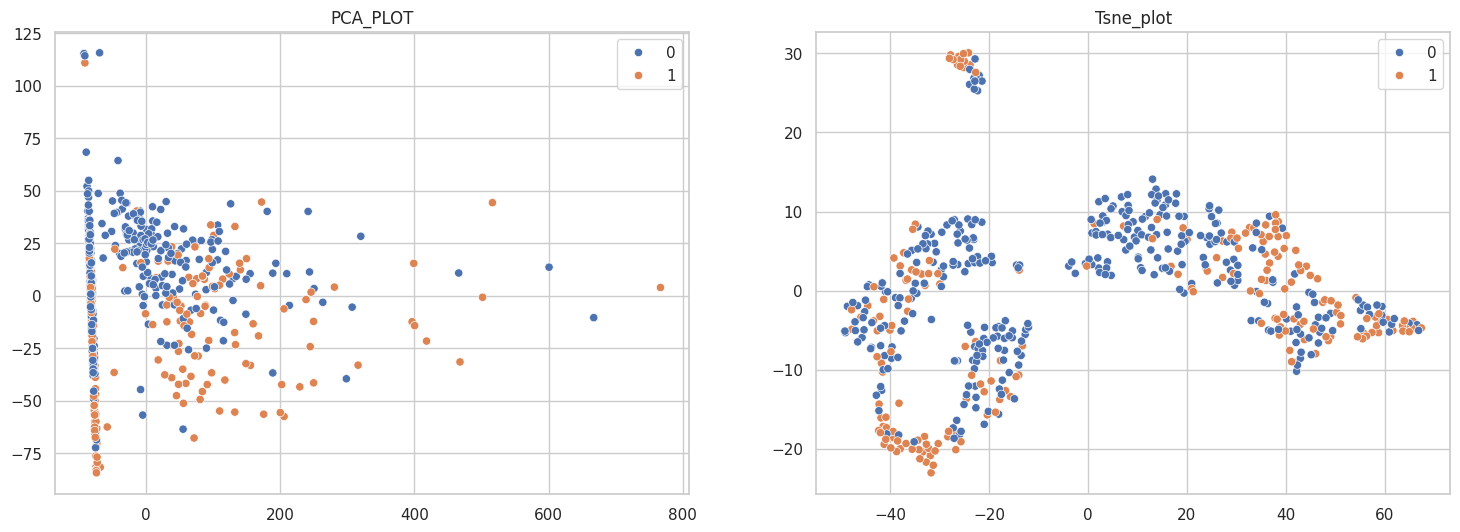

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(18,6), dpi=100)

sns.scatterplot(x=pca_2d[:,0],y=pca_2d[:,1], hue=y_train, ax=axes[0])
axes[0].set_title('PCA_PLOT')
sns.scatterplot(x=tsne_results[:,0],y=tsne_results[:,1], hue=y_train, ax=axes[1])
axes[1].set_title('Tsne_plot')

# Normalização dos dados

#### Standarização

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train_std = StandardScaler().fit_transform(X_train)
X_test_std = StandardScaler().fit_transform(X_test)


# PCA

In [ ]:
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       160
           1       0.61      0.52      0.56        71

    accuracy                           0.75       231
   macro avg       0.70      0.69      0.69       231
weighted avg       0.74      0.75      0.74       231



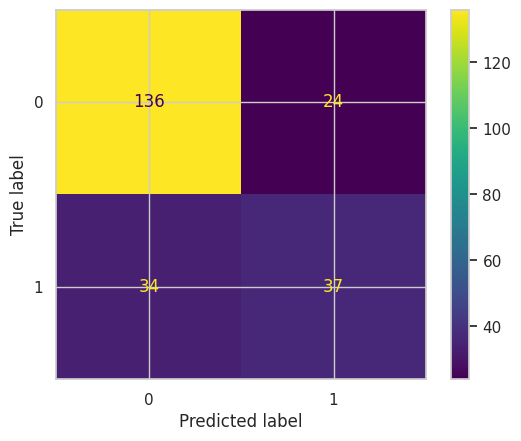

In [ ]:
Classif_KNN = KNeighborsClassifier(n_neighbors=10)
clf = Classif_KNN.fit(X_train_pca, y_train)
pred_y = clf.predict(X_test_pca)

print (classification_report(y_test, pred_y))

cm = confusion_matrix( y_test, pred_y)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

# Autoencoder

In [ ]:
input_layer = Input(shape=(X.shape[1],))
encoded = Dense(100, activation='tanh', activity_regularizer=regularizers.l1(10e-5))(input_layer)
encoded = Dense(50, activation='relu')(encoded)
decoded = Dense(50, activation='tanh')(encoded)
decoded = Dense(100, activation='relu')(decoded)
output_layer = Dense(X.shape[1], activation ='relu')(decoded)

autoencoder = Model(input_layer,output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
y=target.values

In [ ]:
x_perished, x_survived = X_train_std[y_train == 0], X_train_std[y_train == 1]
autoencoder.fit(x_perished, x_perished, epochs = 20, shuffle = True, validation_split = 0.25)

In [ ]:
autoencoder.layers[0]

In [ ]:
hidden_repr = Sequential()
hidden_repr.add(autoencoder.layers[0])
hidden_repr.add(autoencoder.layers[1])
hidden_repr.add(autoencoder.layers[2])


In [ ]:
No_diabetes_hid_rep = hidden_repr.predict(x_perished)
diabetes_hid_rep = hidden_repr.predict(x_survived)

rep_x = np.append(No_diabetes_hid_rep, diabetes_hid_rep, axis = 0)
y_n = np.zeros(No_diabetes_hid_rep.shape[0])
y_f = np.ones(diabetes_hid_rep.shape[0])
rep_y = np.append(y_n, y_f)

In [ ]:
train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, stratify=rep_y, test_size=0.30, random_state=20)
clf = Classif_KNN.fit(train_x, train_y)
pred_y = clf.predict(val_x)

print (classification_report(val_y, pred_y))
print (accuracy_score(val_y, pred_y))

cm = confusion_matrix( val_y, pred_y)
disp = ConfusionMatrixDisplay(cm)
disp.plot()